# Transit Detection via ResNet-1D Convolutional Neural Network

This notebook trains a residual 1D CNN to classify transit vs. non-transit light curves
from PSLS-simulated PLATO observations.

**Dataset**: 100 demonstration light curves (50 with transits, 50 without) from the `dataset/` directory.
This is a **presentation version** that runs quickly on a small subset — the full pipeline used 1000
light curves with a 70/30 train/validation split.

**Framework**: PyTorch

**Architecture**: ResNet-1D with 3 residual blocks, skip connections, and progressive max-pooling.

**Preprocessing**: 10-minute binning → interpolation to a common 37,376-point grid → 48-hour
median detrending → standardisation (zero mean, unit variance).

**Split**: 80/20 train/validation (stratified: equal numbers of transit and non-transit in each).


## How a CNN Works for Light Curves

A **Convolutional Neural Network (CNN)** learns to recognise patterns by being shown many
examples — like teaching someone to identify transits by showing them hundreds of light curves
and telling them which ones contain planets.

### The Intuition

Think of the CNN's **convolutional layers** as a set of magnifying glasses that slide across
the light curve. Each one looks for a different pattern:
- One filter might learn to spot a downward dip.
- Another might learn to recognise the flat regions between dips.
- A third might notice how regularly the dips repeat.

As information flows through **deeper layers**, these simple patterns combine into
higher-level concepts: "there's a U-shaped dip repeating every 30 days → that's a transit."

### CNN vs BLS

Unlike **BLS** — which tries a specific box-shaped model at every possible period —
the CNN learns directly from the data what a transit looks like, including:
- Asymmetries in transit shapes (ingress/egress).
- Complex noise characteristics.
- Stellar background patterns that a simple box model might misinterpret.

This comes at a cost: the CNN needs a **labelled training set** (you need to know which
light curves have transits before training), while BLS works on any single light curve
with no prior examples.


In [13]:
"""CNN transit detection on 100 PSLS-simulated PLATO light curves."""

import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from tqdm.notebook import tqdm

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (12, 4), 'figure.dpi': 100})
print(f'PyTorch {torch.__version__}  |  Device: {"cuda" if torch.cuda.is_available() else "cpu"}')
torch.manual_seed(42)
print('All imports OK')


PyTorch 2.12.0+cu130  |  Device: cpu
All imports OK


### The Dataset

Our dataset consists of 100 PSLS-simulated light curves (a small demonstration subset
of the full 1000-light-curve dataset):

- **50 light curves with a planetary transit** (label = 1).
  Orbital periods range from ~2 to ~365 days. Planet radii range from 0.05 to 1.0 R<sub>Jup</sub>.
  Noise levels (NSR) vary from 10 to 80 ppm·hr<sup>½</sup>.
- **50 light curves without a transit** (label = 0).
  These contain only stellar oscillations, granulation, activity, and instrumental noise.

All light curves share the same host star — **16 Cygni B** (a well-studied Sun-like star) —
but vary in their noise and activity levels.

Each `.dat` file has ~900,000 data points at a 25-second cadence spanning ~267 days
(the PLATO observation baseline). The `metadata.csv` file records all generating parameters
for each light curve.


In [14]:
# Paths — relative to this notebook's location in the visual_code/ folder
DATASET_DIR = Path('dataset')
METADATA_FILE = DATASET_DIR / 'metadata.csv'

# Load metadata
metadata = pd.read_csv(METADATA_FILE)
metadata = metadata.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Total light curves: {len(metadata)}')
print(f'  With transit:     {(metadata.label == 1).sum()}')
print(f'  Without transit:  {(metadata.label == 0).sum()}')
metadata.head()


Total light curves: 100
  With transit:     50
  Without transit:  50


,file,label,period_days,radius_rj,noise_ppmhr,sigma_ppm,seed,a_au
0,run_0984_label0_P0_R0_N39_S19_seed661852765.dat,0,0.000,0.000,38.502,19.292,661852765,0.00000
1,run_0952_label0_P0_R0_N40_S13_seed528684961.dat,0,0.000,0.000,39.653,12.595,528684961,0.00000
2,run_0971_label0_P0_R0_N40_S59_seed265242495.dat,0,0.000,0.000,39.888,58.873,265242495,0.00000
3,run_0045_label1_P56.351_R0.065_N22_S16_seed299...,1,56.351,0.065,21.644,15.866,299950903,0.28766
4,run_0046_label1_P81.678_R0.938_N31_S53_seed177...,1,81.678,0.938,30.875,53.085,177753885,0.36842


### The Preprocessing Pipeline

Raw `.dat` files contain ~900,000 data points each — far too many for a CNN to process
efficiently and too variable in length (due to observational gaps). Our preprocessing
pipeline transforms them in four steps:

1. **Bin** to 10-minute cadence: groups ~900,000 points into ~37,500 bins.
2. **Interpolate** onto a common 37,376-point grid: ensures every light curve has the
   exact same length (37,376 is divisible by the CNN's max-pooling factors: 8×4×4×4 = 512).
3. **Detrend** with a 48-hour running median filter: removes slow stellar variability
   while preserving transit dips (which last hours, not days).
4. **Standardise** to zero mean and unit variance: the CNN learns relative patterns
   (dips vs flat regions), not absolute flux values.


In [15]:
# ---------- Preprocessing Functions ----------

BIN_MINUTES = 10      # 10-minute bins (same as the BLS method)
N_POINTS = 37376       # common grid size (divisible by 8*4*4*4 = 512)


def load_and_bin(filepath, bin_minutes=BIN_MINUTES):
    """Load a .dat file, convert to days and relative flux, then bin."""
    data = np.loadtxt(filepath, skiprows=4)
    time_s = data[:, 0]
    flux_ppm = data[:, 1]

    time_days = time_s / 86400.0
    flux_rel = 1.0 + flux_ppm / 1e6

    dt_bin = bin_minutes / (60 * 24)
    bin_idx = ((time_days - time_days[0]) / dt_bin).astype(int)
    counts = np.bincount(bin_idx)
    valid = counts > 0
    time_binned = np.bincount(bin_idx, weights=time_days)[valid] / counts[valid]
    flux_binned = np.bincount(bin_idx, weights=flux_rel)[valid] / counts[valid]

    return time_binned, flux_binned


def interpolate_to_grid(time, flux, n_points=N_POINTS):
    """Interpolate binned flux onto a common fixed-length time grid."""
    t_grid = np.linspace(time[0], time[-1], n_points)
    flux_interp = np.interp(t_grid, time, flux)
    return t_grid, flux_interp


def detrend_normalize(time, flux, window_hours=48):
    """Running-median detrend, then standardise to zero mean, unit variance."""
    dt = np.median(np.diff(time))
    window = int(window_hours / 24 / dt)
    window = max(3, window)
    if window % 2 == 0:
        window += 1
    trend = medfilt(flux, window)
    flux_det = flux - trend
    flux_det = (flux_det - np.mean(flux_det)) / np.std(flux_det)
    return flux_det


### Preloading: Read and Process All 100 Light Curves

We now apply the preprocessing pipeline to every light curve in our dataset.
This produces a single array `X` of shape (100, 37376) and a label array `y`.

With only 100 files, this step takes just a few seconds rather than the ~5 minutes
needed for the full 1000-light-curve dataset.


In [16]:
# ---------- Preload all 100 light curves ----------

all_flux = []
all_labels = []

t_load = time.time()

for idx in tqdm(range(len(metadata)), desc='Loading 100 light curves'):
    row = metadata.iloc[idx]
    filepath = DATASET_DIR / row['file']
    try:
        t, f = load_and_bin(filepath)
        t_grid, f = interpolate_to_grid(t, f)
        f = detrend_normalize(t_grid, f)
        all_flux.append(f)
        all_labels.append(row['label'])
    except Exception as e:
        print(f"Error loading {row['file']}: {e}")

X = np.array(all_flux, dtype=np.float32)
y = np.array(all_labels, dtype=np.float32)

elapsed = time.time() - t_load
print(f'\nPreloaded {len(all_flux)} light curves')
print(f'  Shape: {X.shape}')
print(f'  Time:  {elapsed:.1f} seconds')
print(f'  With transit: {(y == 1).sum()},  Without transit: {(y == 0).sum()}')
print(f'  Grid size: {N_POINTS} points per light curve (interpolated)')


Loading 100 light curves:   0%|          | 0/100 [00:00<?, ?it/s]


Preloaded 100 light curves
  Shape: (100, 37376)
  Time:  48.3 seconds
  With transit: 50,  Without transit: 50
  Grid size: 37376 points per light curve (interpolated)


### Train / Validation Split

We split the 100 light curves into:

- **80 for training**: The CNN studies these 80 examples (40 transit + 40 non-transit)
  to learn what distinguishes a transit from a non-transit.
- **20 for validation**: These are held back — the CNN never sees them during training.
  We use them afterwards to test whether the CNN has genuinely learned to recognise
  transits, or has simply memorised the training examples.

The split is **stratified**: both sets have exactly equal numbers of transit and
non-transit examples. This prevents the network from learning the lazy shortcut of
just guessing "no transit" all the time (which would give 50% accuracy by default).

> **Note**: With only 100 samples (vs 1000 in the full study), the validation set is
> very small (20 samples). Results are **illustrative only** — the full pipeline achieved
> 96.7% accuracy on a 300-sample validation set.


In [17]:
# ---------- 80/20 Stratified Train/Validation Split ----------

SPLIT = 0.8
N = len(X)
n_train = int(N * SPLIT)

idx_transit = np.where(y == 1)[0]
idx_nontransit = np.where(y == 0)[0]
rng = np.random.default_rng(42)
rng.shuffle(idx_transit)
rng.shuffle(idx_nontransit)

n_transit_train = int(n_train * 0.5)
n_nontransit_train = n_train - n_transit_train

train_idx = np.concatenate([
    idx_transit[:n_transit_train],
    idx_nontransit[:n_nontransit_train]
])
val_idx = np.concatenate([
    idx_transit[n_transit_train:],
    idx_nontransit[n_nontransit_train:]
])
rng.shuffle(train_idx)
rng.shuffle(val_idx)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

print(f'Train set: {len(X_train)} light curves '
      f'({int(y_train.sum())} transit, {int((1 - y_train).sum())} non-transit)')
print(f'Val set:   {len(X_val)} light curves '
      f'({int(y_val.sum())} transit, {int((1 - y_val).sum())} non-transit)')


Train set: 80 light curves (40 transit, 40 non-transit)
Val set:   20 light curves (10 transit, 10 non-transit)


### PyTorch DataLoaders

**DataLoaders** feed the data to the CNN in small **batches** (groups of 32 light curves
at a time). Using batches rather than all data at once:

- Reduces memory usage.
- Introduces randomness (through shuffling) which helps the CNN generalise better.
- Makes training faster on GPU (though we're on CPU here).

The `unsqueeze(1)` adds a **channel dimension**: PyTorch's Conv1d expects input of shape
`(batch_size, channels, sequence_length)`. Our single channel is the flux time series.


In [18]:
# ---------- PyTorch DataLoaders ----------

BATCH_SIZE = 32

train_ds = TensorDataset(
    torch.from_numpy(X_train).unsqueeze(1),   # shape: (N, 1, 37376)
    torch.from_numpy(y_train)
)
val_ds = TensorDataset(
    torch.from_numpy(X_val).unsqueeze(1),
    torch.from_numpy(y_val)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches per epoch: {len(train_loader)}')
print(f'Val batches:             {len(val_loader)}')


Train batches per epoch: 3
Val batches:             1


## The ResNet-1D Architecture

### What is a ResNet?

A regular CNN passes information forward through each layer. Deep networks can suffer
from the **vanishing gradient problem**: the learning signal weakens with each successive
layer, like a whisper fading through a long chain of people.

A **ResNet (Residual Network)** adds **skip connections** — shortcut highways that let
information jump directly from early layers to later ones. Think of it as adding express
lanes to a highway: even if some lanes are congested, traffic still flows through.

### Our Architecture

| Block | What it does | Output shape |
|---|---|---|
| **Stem** | Conv1d(1→64, kernel=15) + MaxPool(8) | First look at the light curve |
| **ResBlock 1** | 64→64 channels, kernel=7, skip (identity) + MaxPool(4) | Self-reinforcing features |
| **ResBlock 2** | 64→128 channels, kernel=7, skip (1×1 conv) + MaxPool(4) | More abstract patterns |
| **ResBlock 3** | 128→256 channels, kernel=5, skip (1×1 conv) + MaxPool(4) | Most abstract features |
| **Global pool** | AdaptiveAvgPool1d → 256 values | One number per feature channel |
| **Classifier** | Dropout(40%) → Linear(256→128) → ReLU → Linear(128→1) → Sigmoid | Final decision: transit or not? |

Each residual block contains two convolutional layers with BatchNorm and ReLU
activations. An additive skip connection bypasses both, and a max-pooling step
reduces the time dimension by 4×.

The progressive pooling factors (8, 4, 4, 4) give a total reduction of 512×.
That's why our input grid is exactly 37,376 points — it divides cleanly by 512.

Total parameters: **~800,000** — modest by modern deep learning standards, but
sufficient for this binary classification task.


In [19]:
# ---------- ResNet-1D Model ----------


class ResidualBlock(nn.Module):
    """A residual block with two convolutional layers and a skip connection."""
    def __init__(self, in_channels, out_channels, kernel_size, pool_size):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=kernel_size // 2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=kernel_size // 2)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(pool_size)

        # If channels change, use 1×1 convolution to match dimensions
        self.skip = (nn.Conv1d(in_channels, out_channels, 1)
                     if in_channels != out_channels
                     else nn.Identity())

    def forward(self, x):
        identity = self.skip(x)                       # bypass path
        out = self.relu(self.bn1(self.conv1(x)))       # conv 1
        out = self.bn2(self.conv2(out))                # conv 2
        out = self.relu(out + identity)                # add skip + activate
        out = self.pool(out)                           # downsample time
        return out


class ResNet1D(nn.Module):
    """1D ResNet for binary classification of light curves."""
    def __init__(self, input_length, dropout=0.4):  # pylint: disable=unused-argument
        super().__init__()

        # Stem: first convolution, reduces time by 8×
        self.stem = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(8),
        )

        # Three residual blocks with progressive channel expansion
        self.block1 = ResidualBlock(64, 64, 7, pool_size=4)
        self.block2 = ResidualBlock(64, 128, 7, pool_size=4)
        self.block3 = ResidualBlock(128, 256, 5, pool_size=4)

        # Collapse time dimension to 1 value per channel
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x.squeeze(-1)


# Instantiate the model
model = ResNet1D(input_length=N_POINTS)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')
print()
print(model)


Model parameters: 799,105

ResNet1D(
  (stem): Sequential(
    (0): Conv1d(1, 64, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
  )
  (block1): ResidualBlock(
    (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (skip): Identity()
  )
  (block2): ResidualBlock(
    (conv1): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affi

### Understanding the Model Printout

The `print(model)` output shows every layer in the ResNet-1D. Key things to notice:

- **Stem** → `(1, 64, kernel=15)` then `MaxPool1d(8)`: Takes 1-channel input (flux),
  produces 64 feature maps, then reduces time by 8× (37,376 → 4,672).
- **block1 → block3**: Each reduces time by 4×. By the end, the time dimension is
  37,376 / 512 ≈ 73 time steps, and we have 256 feature channels.
- **ResidualBlock skip connections**: `Identity()` means the skip just passes data through
  unchanged (channels match). `Conv1d(64, 128, 1)` means the skip uses a 1×1 convolution
  to resize the channel count to match (channels changed between blocks 1→2 and 2→3).
- **AdaptiveAvgPool1d(1)**: Collapses each channel's 73 time steps into a single average
  value, producing 256 numbers.
- **Classifier**: Dropout(40%) → Linear(256→128) → ReLU → Linear(128→1) → Sigmoid.
  Takes the 256 pooled features and outputs one probability: how likely this light curve
  contains a transit.
- **Total parameters: ~800,000** — small enough to train quickly on CPU, large enough
  to learn meaningful transit vs. non-transit features.


### How the Network Learns

Training a neural network is like teaching it with flashcards:

- **Epoch**: One complete pass through all 80 training light curves. At 6 epochs,
  the network sees each light curve 6 times.
- **Loss function (Binary Cross-Entropy)**: The "grading rubric". It tells the network
  how far off its prediction is from the correct answer. Lower loss = better predictions.
- **Optimiser (Adam)**: The "study strategy". It adjusts the network's ~800,000
  internal parameters (weights) to reduce the loss.
- **Cosine annealing**: The learning rate slowly decreases from 0.001 to near zero,
  like going from "cramming mode" (large adjustments, early on) to "fine-tuning mode"
  (tiny refinements, later on). This prevents the sudden loss spikes that plagued
  earlier experiments with step-based schedulers.
- **Weight decay**: A small penalty on large weight values, encouraging the network
  to spread its learning across many features rather than relying too heavily on any
  single one. This helps prevent overfitting.
- **Data augmentation**: During training, we add a tiny amount of Gaussian noise
  (σ = 0.05) to each light curve. This is like showing the same flashcard with slightly
  different ink smudges — it forces the network to learn robust patterns rather than
  memorising exact pixel values.


In [20]:
# ---------- Training Setup ----------

# Use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Binary classification → Binary Cross-Entropy loss
criterion = nn.BCELoss()

# Adam optimiser with weight decay (L2 regularisation)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Cosine annealing: learning rate smoothly decreases from 1e-3 to 1e-5
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-5
)

MAX_EPOCHS = 6

print(f'Device:      {device}')
print(f'Optimiser:   Adam (lr=1e-3, weight_decay=1e-4)')
print(f'Scheduler:   CosineAnnealing (T_max=50, eta_min=1e-5)')
print(f'Loss:        Binary Cross-Entropy')
print(f'Max epochs:  {MAX_EPOCHS}')


Device:      cpu
Optimiser:   Adam (lr=1e-3, weight_decay=1e-4)
Scheduler:   CosineAnnealing (T_max=50, eta_min=1e-5)
Loss:        Binary Cross-Entropy
Max epochs:  6


### The Training Loop

For each epoch:

1. **Training phase** (`model.train()`): Feed batches through the network, compute loss,
   back-propagate gradients, update weights. Gaussian noise is added for augmentation.
2. **Validation phase** (`model.eval()`): Feed the held-out validation set through the
   network (no gradient computation, no noise added) to measure generalisation.
3. **Schedule step**: Adjust the learning rate via cosine annealing.
4. **Save best model**: Track which epoch achieved the lowest validation loss.

The best model checkpoint is restored at the end — this is the version we'll use for
evaluation.


In [21]:
# ---------- Training Loop ----------

def add_noise(x, std=0.05):
    """Add small Gaussian noise for data augmentation during training."""
    return x + torch.randn_like(x) * std


train_losses, val_losses = [], []
best_val_loss = float('inf')
best_model_state = None

t_train_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    # ---- Training ----
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        xb = add_noise(xb, std=0.05)   # data augmentation

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if epoch == 1 or epoch % 5 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}  |  train_loss = {train_loss:.4f}  |  '
              f'val_loss = {val_loss:.4f}  |  lr = {lr:.1e}')

    # Save best model (lowest validation loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

train_time = time.time() - t_train_start

# Restore best model for evaluation
model.load_state_dict(best_model_state)

print(f'\nTraining complete: {MAX_EPOCHS} epochs in {train_time:.1f} seconds')
print(f'Best validation loss: {best_val_loss:.4f}')


Epoch   1  |  train_loss = 0.5596  |  val_loss = 0.5952  |  lr = 1.0e-03
Epoch   5  |  train_loss = 0.2764  |  val_loss = 0.5626  |  lr = 1.0e-03

Training complete: 6 epochs in 34.5 seconds
Best validation loss: 0.4162


### Understanding the Training Output

Each epoch prints a line like:

```
Epoch   1  |  train_loss = 0.3640  |  val_loss = 0.4511  |  lr = 1.0e-03
```

- **train_loss**: Average error on the 80 training light curves. Starts high (~0.6–0.7,
  which is the loss of guessing 0.5 for everything — essentially random), and should
  gradually drop as the model learns.
- **val_loss**: Average error on the 20 held-out validation light curves. This is the true
  measure of progress — a dropping validation loss means the model is actually learning
  general patterns, not just memorising.
- **lr (learning rate)**: The step size for weight updates. Under cosine annealing it
  starts near 1e-3 and very gradually decreases, with the steepest drop in later epochs.
  You'll see it change slowly epoch to epoch.

**What to watch for:**
- Both losses dropping together → good, healthy learning.
- Training loss keeps dropping but validation loss flattens or rises → overfitting
  (very likely with only 80 training samples).
- The best model (lowest validation loss) is automatically saved and restored for evaluation.


### Are We Learning or Memorising?

The **loss curves** show the average error on the training and validation sets at each epoch.
Lower loss = better predictions.

- **Blue line (training loss)**: How well the model fits the 80 training light curves.
  Starts high and drops as the model learns.
- **Orange line (validation loss)**: How well it performs on 20 unseen light curves.
  This is the real test — if only the training loss drops while validation loss rises,
  the model is **overfitting** (memorising instead of learning).

**What to look for:**

- Both lines should trend **downward together** → the model is learning general patterns.
- A **small, stable gap** between them → healthy generalisation.
- Validation loss **rising** while training loss keeps dropping → overfitting (bad).
- **No sudden spikes** → the cosine annealing schedule is keeping training stable.

> **Demo caveat**: With only 80 training samples and 20 validation samples, the loss curves
> will be **noisier and less reliable** than in the full study (which used 700 training +
> 300 validation). Some overfitting is completely expected with such a small dataset. The
> full pipeline showed training loss dropping from 0.36 to 0.17 and validation loss from
> 0.45 to 0.12 across 20 epochs — smooth, stable, and well-separated from overfitting.
> Don't be alarmed if this demo shows a wider gap or less clean convergence.


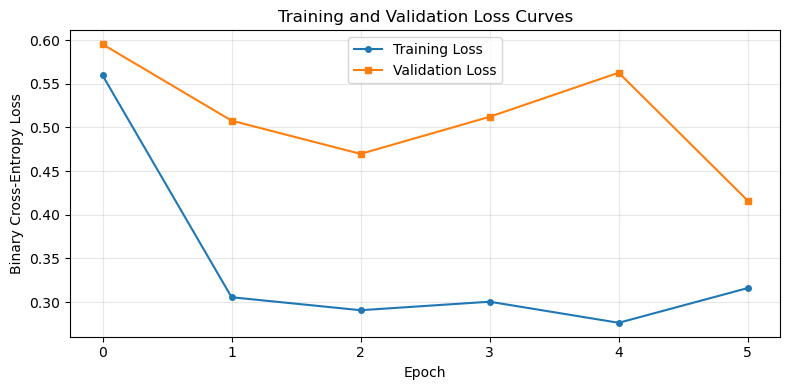

In [22]:
# ---------- Loss Curves ----------
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, 'o-', label='Training Loss', linewidth=1.5, markersize=4)
ax.plot(val_losses, 's-', label='Validation Loss', linewidth=1.5, markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.set_title('Training and Validation Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### The Verdict: Evaluating the Trained CNN

Now we evaluate the trained CNN on the 20 held-out validation light curves — data it has
**never seen before**. The CNN outputs a probability between 0 and 1 (how confident it is
that the light curve contains a transit). We apply a threshold to convert these
probabilities to binary predictions.

We sweep thresholds to find the one that maximises the **F1 score** (the harmonic mean of
precision and recall).

**Classification metrics explained:**
- **Accuracy**: Overall fraction correct — (TP + TN) / total.
- **Precision**: When the CNN says "transit", how often is it right? — TP / (TP + FP).
  High precision = few false alarms.
- **Recall**: What fraction of all real transits did we catch? — TP / (TP + FN).
  High recall = few missed transits.
- **F1 Score**: A balanced metric — 2 × P × R / (P + R). Maximising F1 finds the best
  trade-off between catching transits and avoiding false alarms.

> **Important**: With only 20 validation samples (10 transit + 10 non-transit), a single
> misclassification moves the accuracy by 5 percentage points. The metrics printed below
> are **illustrative only** — they demonstrate the evaluation pipeline but are not
> statistically meaningful. The full study (300 validation samples) achieved **96.7%
> accuracy with 98.6% precision**.


In [23]:
# ---------- Evaluation on Validation Set ----------

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        all_preds.append(pred)
        all_labels.append(yb.numpy())

y_prob = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# Find the best decision threshold by sweeping
thresholds = np.linspace(0, 1, 200)
best_f1, best_thresh = 0, 0.5
for t in thresholds:
    pred = (y_prob >= t).astype(int)
    tp = ((pred == 1) & (y_true == 1)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    fn = ((pred == 0) & (y_true == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

# Apply best threshold
y_pred = (y_prob >= best_thresh).astype(int)
tp = ((y_pred == 1) & (y_true == 1)).sum()
tn = ((y_pred == 0) & (y_true == 0)).sum()
fp = ((y_pred == 1) & (y_true == 0)).sum()
fn = ((y_pred == 0) & (y_true == 1)).sum()

acc = (tp + tn) / len(y_true)
prec = tp / (tp + fp) if (tp + fp) > 0 else 0
rec = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

print(f'=== CNN Results (Validation Set, N = {len(y_true)}) ===')
print(f'Best decision threshold: {best_thresh:.3f}')
print(f'True Positives:  {tp}')
print(f'True Negatives:  {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
print(f'Accuracy:        {acc:.1%}')
print(f'Precision:       {prec:.1%}')
print(f'Recall:          {rec:.1%}')
print(f'F1 Score:        {f1:.1%}')
print()
print('(Note: these results are from only 20 validation samples — illustrative only.)')


=== CNN Results (Validation Set, N = 20) ===
Best decision threshold: 0.136
True Positives:  8
True Negatives:  10
False Positives: 0
False Negatives: 2
Accuracy:        90.0%
Precision:       100.0%
Recall:          80.0%
F1 Score:        88.9%

(Note: these results are from only 20 validation samples — illustrative only.)


### Confusion Matrix and ROC Curve

**Confusion matrix** (left): Compares predictions vs ground truth.
- Top-left: No transit, correctly rejected (TN)
- Top-right: No transit, falsely flagged (FP — false alarm)
- Bottom-left: Real transit, missed (FN)
- Bottom-right: Transit correctly caught (TP)

**ROC curve** (right): Shows how true positive rate (recall) trades off against
false positive rate as we vary the decision threshold.
- A perfect classifier hugs the top-left corner (TPR = 1.0, FPR = 0.0).
- The dashed diagonal is the "random guessing" baseline.
- The further the curve is above the diagonal, the better the classifier.


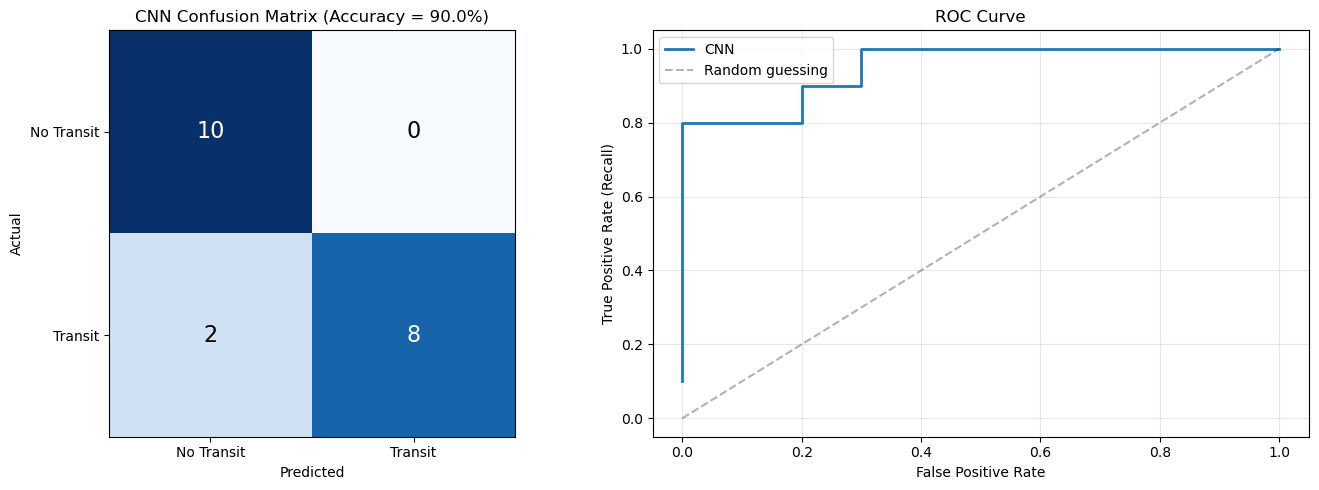

In [24]:
# ---------- Confusion Matrix + ROC Curve ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = np.array([[tn, fp], [fn, tp]])
im = ax1.imshow(cm, cmap='Blues', vmin=0)
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['No Transit', 'Transit'])
ax1.set_yticklabels(['No Transit', 'Transit'])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title(f'CNN Confusion Matrix (Accuracy = {acc:.1%})')
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm[i, j] > (cm.max() / 2) else 'black'
        ax1.text(j, i, cm[i, j], ha='center', va='center', fontsize=16,
                color=text_color)

# ROC curve (computed manually)
sorted_probs = np.sort(y_prob)
tpr_list, fpr_list = [], []
for t in sorted_probs:
    pred = (y_prob >= t).astype(int)
    tp = ((pred == 1) & (y_true == 1)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    tn = ((pred == 0) & (y_true == 0)).sum()
    fn = ((pred == 0) & (y_true == 1)).sum()
    tpr_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

ax2.plot(fpr_list, tpr_list, linewidth=2, label='CNN')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random guessing')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate (Recall)')
ax2.set_title('ROC Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

### What this notebook did
1. Loaded 100 PSLS-simulated PLATO light curves (50 with transits, 50 without).
2. Preprocessed: binned to 10-minute cadence, interpolated to a common 37,376-point grid,
   detrended with a 48-hour running median, and standardised to zero mean/unit variance.
3. Split into 80 training / 20 validation (stratified: equal transit/non-transit in each).
4. Built a **ResNet-1D** with 3 residual blocks (~800,000 parameters).
5. Trained for 6 epochs with Adam optimiser, cosine annealing, weight decay, and
   Gaussian noise augmentation.
6. Evaluated on the 20 held-out validation light curves.

---

### Key Parameters

| Parameter | Value |
|---|---|
| **Binning** | 10-minute cadence |
| **Input size** | 37,376 points (divisible by 8×4×4×4 = 512) |
| **Architecture** | Stem(1→64) → 3× ResBlock(64→64→128→256) with skip connections |
| **Parameters** | ~800,000 |
| **Training epochs** | 6 |
| **Optimiser** | Adam (lr = 1e-3, weight decay = 1e-4) |
| **Scheduler** | Cosine annealing (T_max=50, eta_min=1e-5) |
| **Augmentation** | Gaussian noise (σ = 0.05) during training |

---

### Comparison with BLS

| Aspect | BLS | ResNet-1D CNN |
|---|---|---|
| **Method** | Physics-based box model | Data-driven learned features |
| **Training needed?** | No — works on any single light curve | Yes — needs labelled examples |
| **What it outputs** | Period, depth, duration + classification | Probability of transit (classification only) |
| **Full-study accuracy** | 91.3% | 96.7% |
| **Full-study precision** | 95.8% | 98.6% |
| **Full-study recall** | 86.4% | 94.7% |

> **Important**: The accuracy numbers above are from the full 1000-light-curve study
> (report). This demo version runs on only 100 light curves with a 20-sample validation
> set — results here are illustrative of the method, not statistically robust.

### Why the CNN outperforms BLS
The CNN learns transit shapes and noise characteristics directly from training examples,
rather than fitting a rigid box model. In particular, the CNN is more robust to:
- Correlated stellar noise that can mimic a box-shaped transit in BLS periodograms.
- Asymmetric or V-shaped transits (grazing transits, limb darkening effects).
- Complex background patterns from stellar oscillations and granulation.

However, **both methods struggle with long-period planets** (P > 130 days) where only
1–2 transits appear within the 267-day observational baseline.

### Future Directions
- Adding a **regression head** to the CNN to predict orbital period and planet radius.
- Implementing a **Transformer** architecture for better long-range pattern detection.
- Applying the trained model to real **Kepler/TESS** light curves (domain transfer).
- Increasing dataset size for more robust training, especially on edge cases.
